# Introduction
Smart charging adapts to fluctuations in electricity supply and demand, typically shifting charging to periods of low overall consumption (often at night) or when there is an abundance of renewable energy, such as solar or wind power (Vattenfall, 2025).

Charge Point Operators (CPOs) can optimize the charging process to reduce stress on the electricity grid during peak periods, while also promoting a more sustainable and cost-effective use of energy resources (Equans, 2025).

In this notebook, we analyze peak demand periods based on hourly and daily electricity consumption patterns. Additionally, we examine the cost of electricity to identify opportunities for load shifting and cost reduction.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("/kaggle/input/electric-vehicle-charging-patterns/ev_charging_patterns.csv",
                parse_dates=["Charging Start Time", "Charging End Time"])

df.sample(n = 5)

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,User ID,Vehicle Model,Battery Capacity (kWh),Charging Station ID,Charging Station Location,Charging Start Time,Charging End Time,Energy Consumed (kWh),Charging Duration (hours),Charging Rate (kW),Charging Cost (USD),Time of Day,Day of Week,State of Charge (Start %),State of Charge (End %),Distance Driven (since last charge) (km),Temperature (°C),Vehicle Age (years),Charger Type,User Type
1234,User_1235,Nissan Leaf,100.0,Station_4,San Francisco,2024-02-21 10:00:00,2024-02-21 12:58:00,NaN,1.616070,27.796977,58.254607,Afternoon,Thursday,74.475232,75.870763,58.282293,33.665761,7.0,Level 2,Long-Distance Traveler
1089,User_1090,Tesla Model 3,50.0,Station_265,New York,2024-02-15 09:00:00,2024-02-15 12:47:00,NaN,0.942143,15.415282,31.472932,Night,Tuesday,21.389957,70.375165,266.593025,20.780147,3.0,Level 2,Long-Distance Traveler
849,User_850,Chevy Bolt,85.0,Station_478,New York,2024-02-05 09:00:00,2024-02-05 10:33:00,6.535781,1.705545,13.422391,14.001998,Afternoon,Tuesday,61.580857,77.784277,NaN,36.785727,2.0,DC Fast Charger,Commuter
967,User_968,Hyundai Kona,85.0,Station_219,Los Angeles,2024-02-10 07:00:00,2024-02-10 09:28:00,39.189988,2.728523,19.260046,27.629412,Evening,Saturday,16.990153,86.175568,85.427177,32.825599,5.0,DC Fast Charger,Commuter
1246,User_1247,Chevy Bolt,75.0,Station_219,Los Angeles,2024-02-21 22:00:00,2024-02-22 00:10:00,60.681538,2.215149,15.631492,31.651427,Afternoon,Wednesday,52.460956,69.584656,61.515308,15.954997,2.0,Level 2,Commuter


**Comments**
* Each row represents a single charging session.
* The variables relevant for the smart charging analysis include: Charging Start Time, Charging Duration (hours), Energy Consumed (kWh), and Charging Cost (USD). 
* Note that the Charging Rate (kW) is not simply calculated as Energy Consumed (kWh) / Charging Duration (hours).
* Charging Duration refers to the time required to charge the battery to its target (often maximum) capacity. The Charging End Time is the timestamp when the vehicle is unplugged from the charger, which may be later than when charging was actually completed.

In [2]:
df.dtypes

User ID                                             object
Vehicle Model                                       object
Battery Capacity (kWh)                             float64
Charging Station ID                                 object
Charging Station Location                           object
Charging Start Time                         datetime64[ns]
Charging End Time                           datetime64[ns]
Energy Consumed (kWh)                              float64
Charging Duration (hours)                          float64
Charging Rate (kW)                                 float64
Charging Cost (USD)                                float64
Time of Day                                         object
Day of Week                                         object
State of Charge (Start %)                          float64
State of Charge (End %)                            float64
Distance Driven (since last charge) (km)           float64
Temperature (°C)                                   float

**Comments**
* Charging start time and charging end time have been correctly converted to datetime objects.

In [3]:
# Let's compute the average power consumption by hour. 
df["avg_power_kw"] = df["Energy Consumed (kWh)"] / df["Charging Duration (hours)"]

df.sample(n = 5)

,User ID,Vehicle Model,Battery Capacity (kWh),Charging Station ID,Charging Station Location,Charging Start Time,Charging End Time,Energy Consumed (kWh),Charging Duration (hours),Charging Rate (kW),...,Time of Day,Day of Week,State of Charge (Start %),State of Charge (End %),Distance Driven (since last charge) (km),Temperature (°C),Vehicle Age (years),Charger Type,User Type,avg_power_kw
751,User_752,BMW i3,100.0,Station_307,New York,2024-02-01 07:00:00,2024-02-01 08:24:00,40.319062,1.743607,11.767851,...,Evening,Thursday,31.093089,86.584959,99.187333,0.534567,7.0,Level 1,Casual Driver,23.123940
1204,User_1205,Chevy Bolt,100.0,Station_498,San Francisco,2024-02-20 04:00:00,2024-02-20 06:50:00,45.989184,1.599028,42.364390,...,Evening,Tuesday,63.543474,60.390194,113.455119,5.824782,3.0,Level 1,Casual Driver,28.760717
1012,User_1013,Hyundai Kona,50.0,Station_469,Los Angeles,2024-02-12 04:00:00,2024-02-12 07:35:00,53.206394,3.949096,47.633710,...,Night,Saturday,82.904927,91.603299,146.681512,11.393724,2.0,Level 1,Long-Distance Traveler,13.473056
689,User_690,Chevy Bolt,50.0,Station_144,Chicago,2024-01-29 17:00:00,2024-01-29 19:50:00,79.962226,2.967780,9.807730,...,Afternoon,Friday,20.760172,98.432869,278.475684,4.753258,2.0,Level 2,Long-Distance Traveler,26.943450
23,User_24,Tesla Model 3,100.0,Station_326,New York,2024-01-01 23:00:00,2024-01-01 23:31:00,68.447126,2.071429,49.710307,...,Morning,Friday,19.233139,74.006151,280.915468,3.580840,5.0,DC Fast Charger,Commuter,33.043430


In [4]:
# Calculate the true charging end time
df["Actual Charging End Time"] = df["Charging Start Time"] + pd.to_timedelta(df["Charging Duration (hours)"], unit="h")

# Create a time index from the earliest start to latest actual end time
time_index = pd.date_range(
    start=df["Charging Start Time"].min().floor("D"),
    end=df["Actual Charging End Time"].max().ceil("D"),
    freq="1H"
)

load_profile = pd.Series(0, index=time_index) # create a pandas series with the hours and 0's (which will be filled in later with kWh)

/tmp/ipykernel_13/3795648957.py:5: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  time_index = pd.date_range(


In [5]:
for _, row in df.iterrows(): # loops through every row (i.e. charge session) of the df
    start = row["Charging Start Time"] # Pulls the session’s start timestamp from that row.
    end = row["Actual Charging End Time"] # Pulls the charge session's end timestamp.
    power = row["avg_power_kw"] # Pulls the average charging power (kW) for that session.
    
    # Find overlapping hourly bins
    session_bins = load_profile[start:end].index
    
    for t in session_bins:
        # Define current hour interval
        interval_start = t
        interval_end = t + pd.Timedelta(hours=1)
        
        # Overlap duration in hours
        overlap = (min(end, interval_end) - max(start, interval_start)).total_seconds() / 3600
        if overlap > 0:
            load_profile[t] += power * overlap

/tmp/ipykernel_13/1503497660.py:17: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '60.712345726639356' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  load_profile[t] += power * overlap


In [6]:
profile_by_hour = load_profile.groupby(load_profile.index.hour).mean() # calculates average energy consumpution by hour
profile_by_weekday = load_profile.groupby(load_profile.index.dayofweek).mean() # calculates average energy consumption by day of week

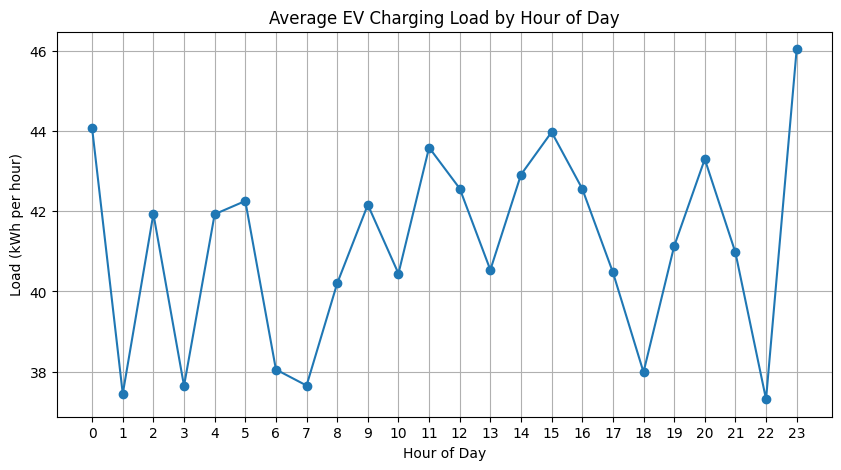

In [7]:
# Hourly average load
plt.figure(figsize=(10,5))
profile_by_hour.plot(marker="o")

plt.title("Average EV Charging Load by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Load (kWh per hour)")
plt.grid(True)

# Set x-axis ticks to show 00:00 to 23:00
plt.xticks(ticks=range(24))

plt.show()

**Comments**
* High charging demand is observed at 00:00, 15:00, and 23:00.
* Low charging demand occurs at 01:00, 03:00, 07:00, and 22:00.
* Charging demand varies significantly throughout the day.

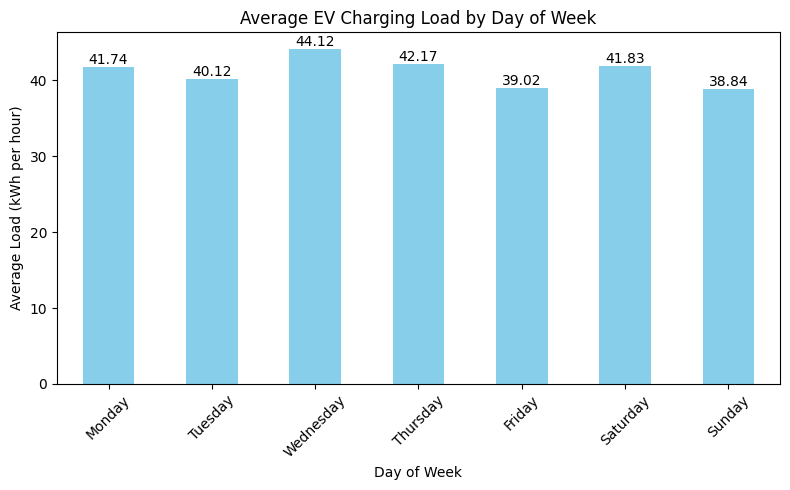

In [8]:
import matplotlib.pyplot as plt

# List of weekday names 
weekday_labels = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Plot
plt.figure(figsize=(8,5))
ax = profile_by_weekday.plot(kind="bar", color="skyblue", legend=False)

# Customize plot
plt.title("Average EV Charging Load by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Load (kWh per hour)")

# Set custom x-axis labels
plt.xticks(ticks=range(7), labels=weekday_labels, rotation=45)  # Rotate for readability

# Add value labels on top of bars
for p in ax.patches:
    height = p.get_height()
    ax.text(
        p.get_x() + p.get_width() / 2,  
        height + 0.02,                  
        f'{height:.2f}',                
        ha='center', va='bottom'       
    )

plt.tight_layout()
plt.show()

**Comments**
* High charging demand occurs on Wednesdays.
* Low charging demand occurs on Fridays.

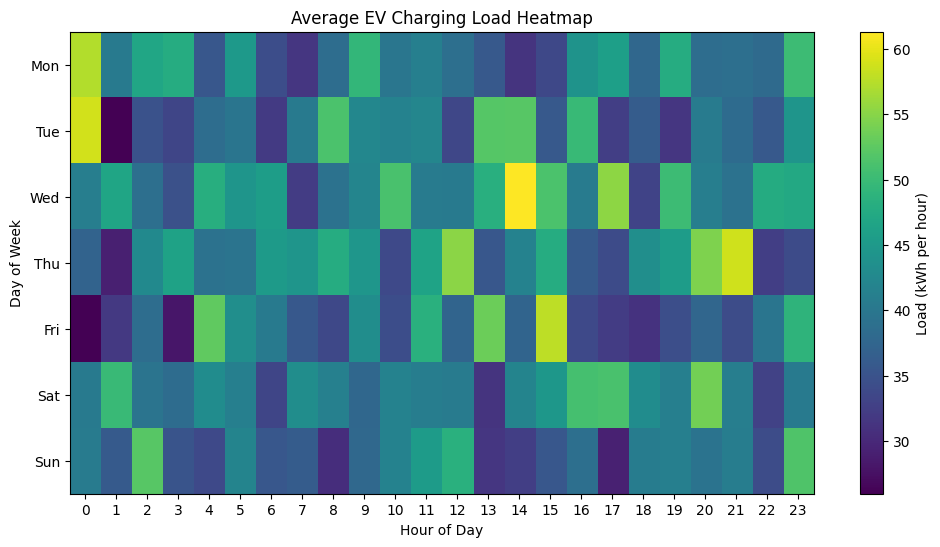

In [9]:
# Heatmap: weekday vs hour of day
heatmap_data = load_profile.groupby([load_profile.index.dayofweek, load_profile.index.hour]).mean().unstack()
plt.figure(figsize=(12,6))
plt.imshow(heatmap_data, aspect="auto", cmap="viridis")
plt.colorbar(label="Load (kWh per hour)")
plt.xticks(range(24), range(24))
plt.yticks(range(7), ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"])
plt.title("Average EV Charging Load Heatmap")
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")
plt.show()

**Comments**
* Charging demand is high at midnight (00:00) on Monday and Tuesday.
* The peak demand occurs on Wednesday at 14:00.

In [10]:
# Calculate the charging cost by energy consumed
df["cost_per_kWh"] = df["Charging Cost (USD)"] / df["Energy Consumed (kWh)"]

In [11]:
df_expanded = []

for _, row in df.iterrows():
    start = row["Charging Start Time"]
    end = row["Actual Charging End Time"]  # Start + Duration
    hours = pd.date_range(start=start.floor('H'), end=end.ceil('H'), freq='1H')
    hours = hours[hours < end]  # remove the last hour if it exceeds actual end

    for hour in hours:
        df_expanded.append({
            "hour": hour.hour,
            "cost_per_kWh": row["cost_per_kWh"]  # full session cost per kWh
        })

df_hours = pd.DataFrame(df_expanded)

/tmp/ipykernel_13/1909949143.py:6: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hours = pd.date_range(start=start.floor('H'), end=end.ceil('H'), freq='1H')


In [12]:
# Calculate the average charging cost by hour
avg_cost_per_kWh_by_hour = df_hours.groupby("hour")["cost_per_kWh"].mean()

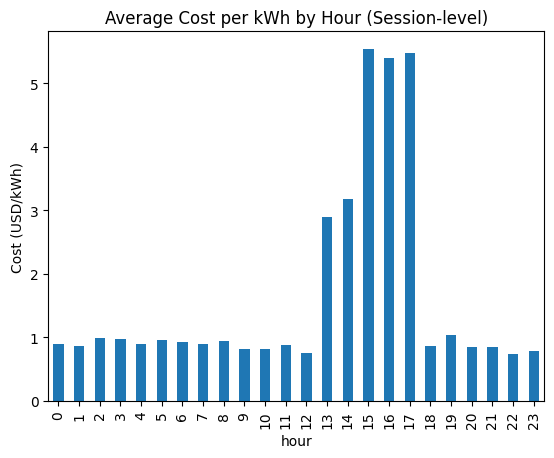

In [13]:
# Create plot to show the average cost per kWh
avg_cost_per_kWh_by_hour.plot(
    kind="bar", 
    title="Average Cost per kWh by Hour (Session-level)",
    ylabel="Cost (USD/kWh)"
)
plt.show()

**Comments**
* Electricity prices are highest during peak hours, which fall between 15:00 and 17:00.

# Managerial recommendations

**Target hours to avoid: 00:00, 15:00, and 23:00**
(Periods with the highest charging demand)

Recommended Actions:
- Implement dynamic pricing with higher rates during these peak hours.
- Allow users to input their preferred end time in the app, enabling the system to optimize charging schedules and avoid these peak periods.

**Target weekdays to avoid: Wednesday, Thursday, and Saturday**
(Days with the highest charging demand)

Recommended Actions:
- Offer incentives to encourage users to charge their vehicles on days other than these peak days.
- Display real-time pricing and load status on the charging stations to inform and guide users.

**Recommended charging windows based on cost of energy: early morning (00:00 – 12:00) and evening (18:00 – 23:00)**
(Periods when electricity costs are lowest)

Recommended Actions:
- Integrate smart charging schedules in apps or vehicle software to automatically initiate charging during these low-cost windows.
- Encourage overnight charging to maximize the use of affordable electricity.

# References
* https://www.vattenfall.nl/laadpaal/slim-laden/
* https://equans.nl/nieuws/actief-slim-laden-proef-met-financiele-prikkel-voor-e-rijder-onderzoekt-ontlasting-stroomnet/